# Import of packages and arguments needed for data visualization

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import os

import importlib
import utils
from logger import ExperimentLogger

importlib.reload(utils)
argFile = 'parameters.json'
try:
    del args
except NameError:
    pass
args = utils.loadJson(argFile)    
    
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

In [141]:
def check_keys_inside_file(runs=False):
    # 2. Extract and display unique parameters
    if not runs:
        print("No runs found in this file or file doesn't exist.")
    else:
        print(f"Total number of logged runs: {len(runs)}\n")
        print("--- UNIQUE PARAMETERS INSIDE THE FILE ---")

        # Grab all metadata keys present in the first run to build our search list
        metadata_keys = runs[0]["metadata"].keys()

        for key in metadata_keys:
            # Use a set comprehension to gather every unique value seen across runs
            unique_values = {run["metadata"].get(key) for run in runs if key in run["metadata"]}

            # Sort if possible for clean reading (falls back to unsorted if types mismatch)
            try:
                sorted_values = sorted(list(unique_values))
            except TypeError:
                sorted_values = list(unique_values)

            print(f"  * {key:<12} : {sorted_values}")
          
runs = ExperimentLogger.load_group(path_to_sim)
runs_ODEs = ExperimentLogger.load_group(path_to_sim_ODEs)

print("checking for sims :")  
check_keys_inside_file(runs)
print("checking for ODEs")
check_keys_inside_file(runs_ODEs)

checking for sims :
No runs found in this file or file doesn't exist.
checking for ODEs
Total number of logged runs: 20

--- UNIQUE PARAMETERS INSIDE THE FILE ---
  * N            : [1000]
  * M            : [5]
  * K            : [10]
  * rho          : [0.5]
  * alpha        : [70]
  * beta         : [1]
  * L            : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  * W_selection  : [False]
  * A_only       : [False, True]
  * alpha_W      : [0.2]
  * alpha_H      : [0.2]
  * alpha_a      : [0.2]
  * alpha_b      : [0.2]
  * method       : ['LoRA', 'standard']


In [142]:
def check_match_in_keys(runs=False):
    if not runs:
        print("The file is completely empty or doesn't exist.")
    else:
        meta = runs[0]["metadata"]
        print("--- LIVE PARAMETER DEBUGGER ---")
        print(f"{'Parameter':<12} | {'Inside File (meta)':<20} | {'Current Script (args)':<20} | Match?")
        print("-" * 65)

        # Helper to check type-agnostic matches
        def check(v1, v2, is_float=False):
            if is_float:
                return np.isclose(float(v1), float(v2))
            if str(v1).lower() in ['true', 'false'] or str(v2).lower() in ['true', 'false']:
                b1 = str(v1).lower() in ['true', '1']
                b2 = str(v2).lower() in ['true', '1']
                return b1 == b2
            return str(v1) == str(v2)

        # Test every single constraint from your match function
        print(f"{'L':<12} | {str(meta.get('L')):<20} | {str(getattr(args, 'L', 'MISSING')):<20} | {check(meta.get('L'), getattr(args, 'L', None))}")
        print(f"{'beta':<12} | {str(meta.get('beta')):<20} | {str(getattr(args, 'beta', 'MISSING')):<20} | {check(meta.get('beta'), getattr(args, 'beta', None), True)}")
        print(f"{'method':<12} | {str(meta.get('method')):<20} | {str(getattr(args, 'method', 'MISSING')):<20} | {check(meta.get('method'), getattr(args, 'method', None))}")
        print(f"{'rho':<12} | {str(meta.get('rho')):<20} | {str(getattr(args, 'rho', 'MISSING')):<20} | {check(meta.get('rho'), getattr(args, 'rho', None), True)}")
        print(f"{'M':<12} | {str(meta.get('M')):<20} | {str(getattr(args, 'M', 'MISSING')):<20} | {check(meta.get('M'), getattr(args, 'M', None))}")
        print(f"{'K':<12} | {str(meta.get('K')):<20} | {str(getattr(args, 'K', 'MISSING')):<20} | {check(meta.get('K'), getattr(args, 'K', None))}")
        print(f"{'N':<12} | {str(meta.get('N')):<20} | {str(getattr(args, 'N', 'MISSING')):<20} | {check(meta.get('N'), getattr(args, 'N', None))}")
        print(f"{'A_only':<12} | {str(meta.get('A_only')):<20} | {str(getattr(args, 'A_only', 'MISSING')):<20} | {check(meta.get('A_only'), getattr(args, 'A_only', None))}")
        print(f"{'alpha':<12} | {str(meta.get('alpha')):<20} | {str(getattr(args, 'alpha', 'MISSING')):<20} | {check(meta.get('alpha'), getattr(args, 'alpha', None), True)}")
        
        
runs = ExperimentLogger.load_group(path_to_sim)
runs_ODEs = ExperimentLogger.load_group(path_to_sim_ODEs)
print("checking for sims :")  
check_match_in_keys(runs)
print("checking for ODEs")
check_match_in_keys(runs_ODEs)

checking for sims :
The file is completely empty or doesn't exist.
checking for ODEs
--- LIVE PARAMETER DEBUGGER ---
Parameter    | Inside File (meta)   | Current Script (args) | Match?
-----------------------------------------------------------------
L            | 1                    | 10                   | False
beta         | 1                    | 1                    | True
method       | LoRA                 | LoRA                 | True
rho          | 0.5                  | 0.5                  | True
M            | 5                    | 5                    | True
K            | 10                   | 10                   | True
N            | 1000                 | 1000                 | True
A_only       | False                | True                 | False
alpha        | 70                   | 70                   | True


# Import the data from past runs with constraints

In [144]:
def load_runs_with_constraints(path, args):
    runs = ExperimentLogger.load_group(path)

    # Convert string representations like "false", "False", or 0 safely to Python Booleans
    def to_bool(val):
        if isinstance(val, str):
            return val.lower() in ("true", "1")
        return bool(val)

    def match(meta):
        return (
            int(meta["L"]) == int(args.L) and
            float(meta["beta"]) == float(args.beta) and
            str(meta["method"]) == str(args.method) and
            np.isclose(float(meta["rho"]), float(args.rho)) and
            int(meta["M"]) == int(args.M) and
            int(meta["K"]) == int(args.K) and
            int(meta["N"]) == int(args.N) and
            to_bool(meta["A_only"]) == to_bool(args.A_only) and 
            float(meta["alpha"]) == float(args.alpha)
        )

    filtered = [r for r in runs if match(r["metadata"])]

    if len(filtered) == 0:
        print(f"No matching configurations found in {os.path.basename(path)}!")
        return None

    return filtered

def runs_to_dict(path,args):
    """Load runs with constraints and convert them into a dictionary format suitable for analysis.
    Input:
        path (str): The path to the file containing the runs.
        args (Namespace): The arguments containing the constraints.
    Output:
        dict: A dictionary containing the metadata and logs of the runs, organized by keys.
    """
    runs = load_runs_with_constraints(path, args)
    if runs == None :
        return None
    logs = runs[0]["logs"]

    out = {"metadata": runs[0]["metadata"]}

    # global steps if consistent, otherwise keep per-key
    out["steps"] = {}

    for key, entry in logs.items():
        out["steps"][key] = np.array(entry["steps"])

        values = entry["values"]

        if len(values) == 0:
            continue

        out[key] = np.array(values, dtype=object)

    return out
   
# Load the simulation
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
#
df = runs_to_dict(path_to_sim, args)
df_ODES = runs_to_dict(path_to_sim_ODEs, args)
#
#print(df["metadata"])
#print(df_ODES["metadata"])

configs = {
    "standard": {
        "method": "standard",
        "A_only": False,
        "colors": ["#FA7070", "#FDCEDF"],  # Salmon (Task 1) vs. Pastel Rose (Task 2)
    },
    "LoRA": {
        "method": "LoRA",
        "A_only": False,
        "colors": ["#1D4ED8", "#93C5FD"],  # Royal Blue (Task 1) vs. Light Sky Blue (Task 2)
    },
    "LoRA + procedure": {
        "method": "LoRA",
        "A_only": True,
        "colors": ["#15803D", "#86EFAC"],  # Forest Green (Task 1) vs. Mint Green (Task 2)
    },
}


No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in ODES_K=10_M=5.npy!


# 1. Compare LGS with LoRA setting, show the slowing down of dynamic and slightly smaller forgetting.

In [96]:
def check_label(label_run, args):
    if label_run =="LoRA":
        if args.A_only == True:
            label_run= "LoRA_A_only"
    return label_run
def compare_runs(run1_train, run1_odes, run2_train, run2_odes,
                 label_run1, label_run2):
    """Compare two runs side by sideby plotting their test losses over time.
    Input:
        run1_train (dict): The first training run, containing metadata and logs.
        run1_odes (dict): The first ODE run, containing metadata and logs.
        run2_train (dict): The second training run, containing metadata and logs.
        run2_odes (dict): The second ODE run, containing metadata and logs.
    Output:
        None: This function generates a plot comparing the test losses of the two runs.
    """
    

    label_run1 = check_label(label_run1, args)
    label_run2 = check_label(label_run2, args)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), 
                                   sharex=True,
                                   layout='compressed')
    #Plot parameters
    lw_ODEs = 3
    lw_task_switch = 2
    
    label_symbol_task1= r"$\epsilon^\dagger$"
    label_symbol_task2= r"$\epsilon^\ddagger$"
    legend_label_size = 14
    labelspacing = 0.25
    axis_label_size = 20
    tick_label_size = 13
    alpha_sim = 1
    alpha_ODEs = 0.7
    marker_sim = "o"
    markersize_sim = 7
    markevery_sim = 10
    
    #Axis formatting
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0,0))
    for ax in (ax1, ax2):
        ax.set_xlabel(r"$s$", fontsize=axis_label_size)
        ax.tick_params(axis='both', which='both', length=0)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis='both', labelsize=tick_label_size)
        offset_text = ax.xaxis.get_offset_text()
        offset_text.set_fontsize(tick_label_size)

    
    #Colors for the different methods
    colors = {
        "standard":     ["#FA7070", "#F8BFD4FF"],  # Vibrant Salmon (Task 1) vs. Soft Pastel Rose (Task 2)
        "W_selection":  ["#FAC20C", "#EBD17E"],  # Vibrant Salmon (Task 1) vs. Soft Pastel Rose (Task 2)
        "LoRA":         ["#1D4ED8", "#93C5FD"],  # True Royal Blue (Task 1) vs. Light Sky Blue (Task 2)
        "only_LoRA":    ["#D81DCF", "#CE73C9"],
        "LoRA_A_only":  ["#15803D", "#86EFAC"],  # Deep Forest Green (Task 1) vs. Pale Mint Green (Task 2)
    }
    run1_colors = colors[label_run1]
    run2_colors = colors[label_run2]
    #-------LEFT PLOT---------
    #ODEs
    if run1_odes is not None : 
        loss1 = np.asarray(run1_odes["test_loss_1"], dtype=np.float64)
        t_span = np.arange(len(loss1)) * args.integration_step * args.N
        
        ax1.plot(
            t_span,
            np.log10(np.asarray(run1_odes["test_loss_1"], dtype=np.float64)),
            color=run1_colors[0],
            alpha=alpha_ODEs,
            label=f"{label_symbol_task1} ODE",
            lw=lw_ODEs
        )

        ax1.plot(
            t_span,
            np.log10(np.asarray(run1_odes["test_loss_2"], dtype=np.float64)),
            color=run1_colors[1],
            alpha=alpha_ODEs,
            label=f"{label_symbol_task2} ODE",
            lw=lw_ODEs
        )
    
    #Sim
    if run1_train is not None :
        steps_loss = np.array(run1_train["steps"]["test_loss_1"])
        ax1.plot(
        steps_loss,
        np.log10(np.asarray(run1_train["test_loss_1"], dtype=np.float64)),
        linestyle='None',
        marker=marker_sim,
        markersize=markersize_sim,
        markevery=markevery_sim,
        color=run1_colors[0],
        markerfacecolor="white",    
        markeredgewidth=1.5,        
        alpha=alpha_sim,
        label=f"{label_symbol_task1} sim"
        )

        ax1.plot(
            steps_loss,
            np.log10(np.asarray(run1_train["test_loss_2"], dtype=np.float64)),
            linestyle='None',
            marker=marker_sim,
            markersize=markersize_sim,
            markevery=markevery_sim,
            color=run1_colors[1],
            markerfacecolor="white",    
            markeredgewidth=1.5,        
            alpha=alpha_sim,
            label=f"{label_symbol_task2} sim",
            lw=1
        )

    #-----RIGHT PLOT---------
    #ODE
    if run2_odes is not None : 
        loss1 = np.asarray(run2_odes["test_loss_1"], dtype=np.float64)
        t_span = np.arange(len(loss1)) * args.integration_step * args.N

        ax2.plot(
            t_span,
            np.log10(np.asarray(run2_odes["test_loss_1"], dtype=np.float64)),
            color=run2_colors[0],
            alpha=alpha_ODEs,
            label=f"{label_symbol_task1} ODE",
            lw=lw_ODEs
        )
    
        ax2.plot(
            t_span,
            np.log10(np.asarray(run2_odes["test_loss_2"], dtype=np.float64)),
            color=run2_colors[1],
            alpha=alpha_ODEs,
            label=f"{label_symbol_task2} ODE",
            lw=lw_ODEs
        )
    
    #Sim
    if run2_train is not None : 
        steps_loss = np.array(run2_train["steps"]["test_loss_1"])
        
        ax2.plot(
        steps_loss,
        np.log10(np.asarray(run2_train["test_loss_1"], dtype=np.float64)),
        linestyle='None',
        marker=marker_sim,
        markersize=markersize_sim,
        markevery=markevery_sim,
        color=run2_colors[0],
        markerfacecolor="white",    
            markeredgewidth=1.5,        
        alpha=alpha_sim,
        label=f"{label_symbol_task1} sim"
        )
    
        ax2.plot(
            steps_loss,
            np.log10(np.asarray(run2_train["test_loss_2"], dtype=np.float64)),
            linestyle='None',
            marker=marker_sim,
            markersize=markersize_sim,
            markevery=markevery_sim,
            color=run2_colors[1],
            markerfacecolor="white",    
            markeredgewidth=1.5,        
            alpha=alpha_sim,
            label=f"{label_symbol_task2} sim",
            lw=1
        )
    
    #Extract task switch and make it visible on the plots
    P_time = args.N * args.alpha   
    ax1.axvline(x=P_time, color="grey", lw=lw_task_switch, zorder=1)
    ax2.axvline(x=P_time, color="grey", lw=lw_task_switch, zorder=1)


    #plt.set_title(
    #    f"Test Loss | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, "
    #    f"rank={args.L}, beta={args.beta}, method={args.method}, A_only={args.A_only} \n"
    #)

    #Additional writing, must be done at the end as we use layout="compressed"
    fig.canvas.draw()

    ax1.text(-0.05, 1.05, "(a)", transform=ax1.transAxes,
             fontsize=16, fontweight="bold")
    
    ax2.text(-0.05, 1.05, "(b)", transform=ax2.transAxes,
             fontsize=16, fontweight="bold")
    
    ax1.text(0.95, 0.92, f"{label_run1}", transform=ax1.transAxes, 
             fontsize=16, fontweight="bold", va='top', ha='right')
    ax2.text(0.95, 0.92, f"{label_run2}", transform=ax2.transAxes, 
             fontsize=16, fontweight="bold", va='top', ha='right')
    
    # Unique y axis
    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()
    global_ymin = min(ymin1, ymin2)
    global_ymax = max(ymax1, ymax2)
    unified_ylim = (global_ymin, global_ymax)

    for ax in [ax1, ax2]:
        ax.set_ylim(unified_ylim)
        ax.tick_params(
                axis='y',          
                which='both',      
                left=True,         
                direction='out',   
                length=4,          
                width=1.0          
            )
        ax.grid(
            True,               # Turn grid on
            which='major',      # Only draw major gridlines
            axis='both',        # Draw both horizontal and vertical lines
            linestyle='-',      # Solid lines look cleaner than dashed when faint
            color="#C5BFBF",    # Extremely light gray
            linewidth=0.8,      # Thin footprint
            alpha=0.8,          # Slight transparency blending
            zorder=0            # Push the grid lines completely BEHIND your data curves
        )
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    ax1.set_ylabel(r"$\log \epsilon^*$", fontsize=axis_label_size)
    ax1.legend(frameon=False, loc="lower left", fontsize=legend_label_size, labelspacing=labelspacing)
    ax2.legend(frameon=False, loc="lower left", fontsize=legend_label_size, labelspacing=labelspacing)
    ax2.tick_params(axis='y', which='both', labelleft=False)
    ax2.set_yticklabels([])
    
    
    #plt.tight_layout()

    plt.savefig("for_paper/"
        f"th_sim_N_{args.N}_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_"
        f"{args.method}_A_only_{args.A_only}.pdf"
    )
    plt.show()

No matching configurations found in run_K=10_M=5.npy!


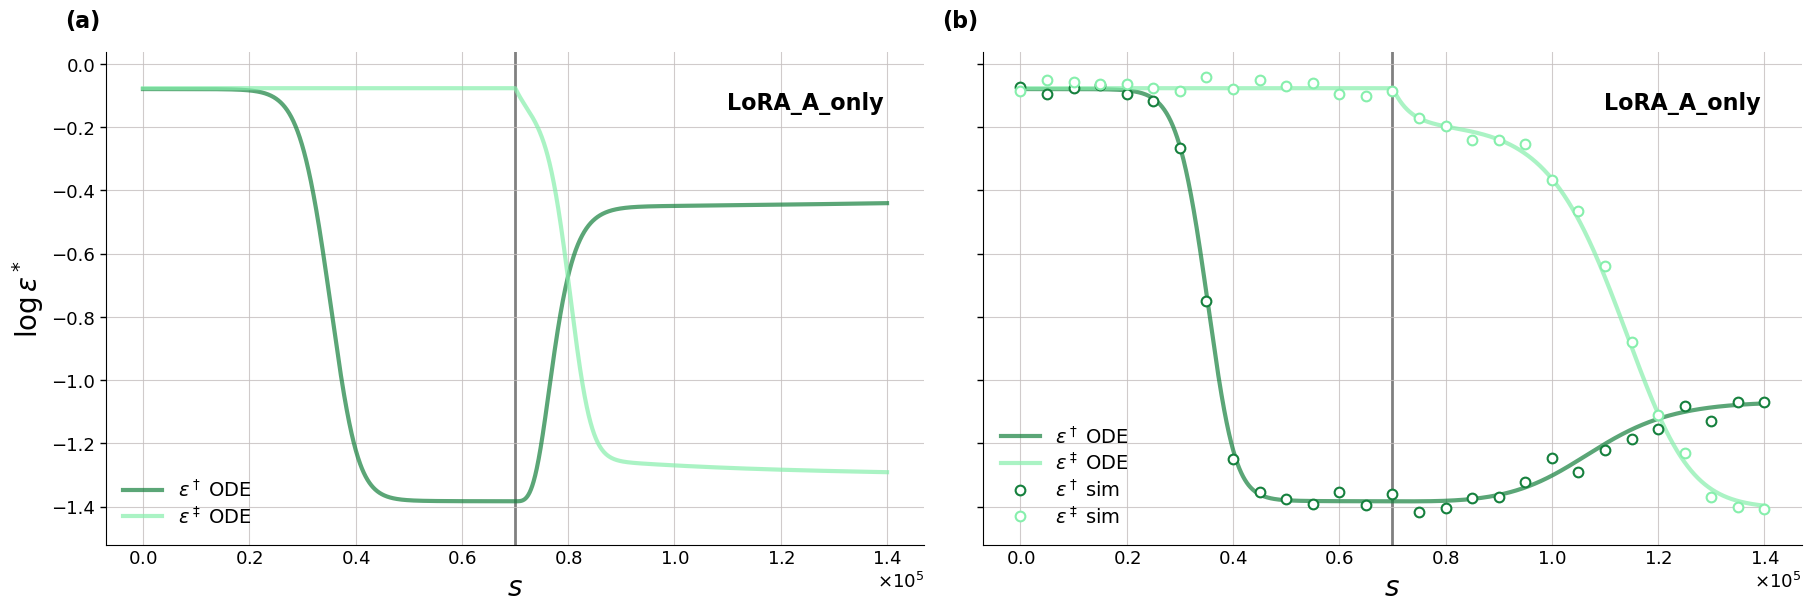

In [107]:
label_run1="LoRA"
label_run2="LoRA"
#
args.method=label_run1
args.A_only = False
df_run1 = runs_to_dict(path_to_sim, args)
df_ODES_run1 = runs_to_dict(path_to_sim_ODEs, args)
#
args.method=label_run2
args.A_only = True
df_run2 = runs_to_dict(path_to_sim, args)
df_ODES_run2 = runs_to_dict(path_to_sim_ODEs, args)



compare_runs(df_run1, df_ODES_run1, df_run2, df_ODES_run2, label_run1=label_run1, label_run2=label_run2)

# 2. Optimal protocol

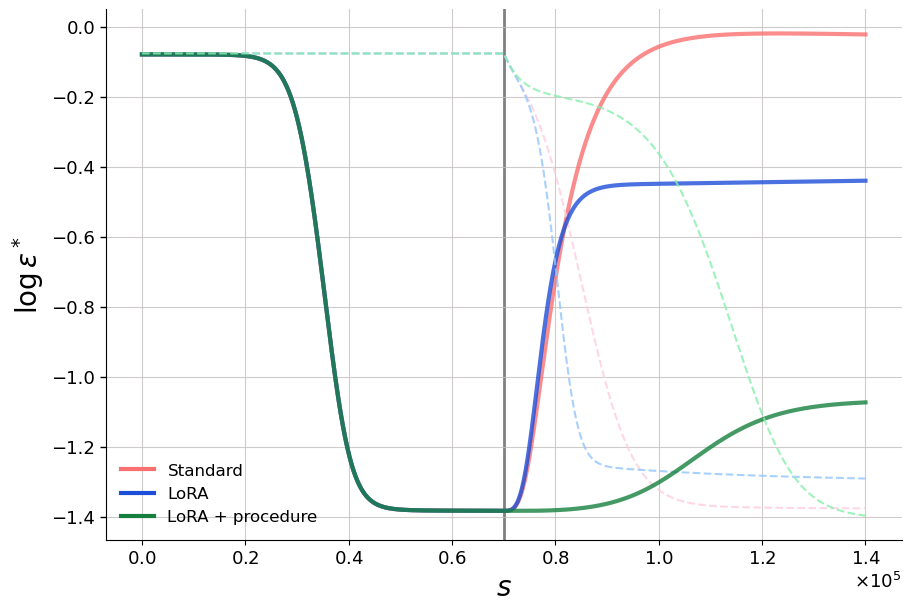

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines

# 1. Configuration Dictionary updated with Salmon, Blue, and Green pairings
configs = {
    "standard": {
        "method": "standard",
        "A_only": False,
        "colors": ["#FA7070", "#FDCEDF"],  # Salmon (Task 1) vs. Pastel Rose (Task 2)
    },
    "LoRA": {
        "method": "LoRA",
        "A_only": False,
        "colors": ["#1D4ED8", "#93C5FD"],  # Royal Blue (Task 1) vs. Light Sky Blue (Task 2)
    },
    "LoRA + procedure": {
        "method": "LoRA",
        "A_only": True,
        "colors": ["#15803D", "#86EFAC"],  # Forest Green (Task 1) vs. Mint Green (Task 2)
    },
}

def select_single_trajectory_run(runs, method, A_only, target_rho):
    """Filters data array down to the exact single run matching the experimental parameters."""
    for r in runs or []:
        meta = r["metadata"]
        if (
            meta["method"] == method
            and bool(meta["A_only"]) == A_only
            and np.isclose(float(meta["rho"]), float(target_rho))
            and int(meta["K"]) == int(args.K)
            and int(meta["M"]) == int(args.M)
            and int(meta["N"]) == int(args.N)
            and int(meta["L"]) == int(args.L)
            and float(meta["alpha"]) == float(args.alpha)
        ):
            return r
    return None

# --- Data Loading ---
path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

# --- Subplot Frame (Single Panel Setup) ---
fig, ax = plt.subplots(figsize=(9, 6), layout='compressed')

# Visual Weights
lw_task1 = 3.0
lw_task2 = 1.5
markevery_sim = 50

# --- The Unified Processing Loop ---
for label, cfg in configs.items():
    sim_run = select_single_trajectory_run(all_sim_runs, cfg["method"], cfg["A_only"], args.rho)
    ode_run = select_single_trajectory_run(all_ode_runs, cfg["method"], cfg["A_only"], args.rho)
    
    if ode_run is None:
        continue  # Safeguard missing data steps
        
    ode_logs = ode_run["logs"]
    if "test_loss_1" not in ode_logs or "test_loss_2" not in ode_logs:
        continue
        
    # Build time track on the fly from the loaded ODE track logs
    loss_ref_1 = np.asarray(ode_logs["test_loss_1"]["values"], dtype=np.float64)
    loss_ref_2 = np.asarray(ode_logs["test_loss_2"]["values"], dtype=np.float64)
    t_span = np.arange(len(loss_ref_1)) * args.integration_step * args.N
    
    # --- THEORY PLOTS (Always rendered) ---
    # Task 1 ODE (Solid Line)
    ax.plot(t_span, np.log10(loss_ref_1),
            color=cfg["colors"][0], linestyle='-', lw=lw_task1, alpha=0.8, zorder=2)
    
    # Task 2 ODE (Dashed Line) - Fixed indentation so it always plots
    ax.plot(t_span, np.log10(loss_ref_2),
            color=cfg["colors"][1], linestyle='--', lw=lw_task2, alpha=0.8, zorder=2)
    
    # --- EMPIRICAL SIMULATION PLOTS (Rendered if files exist) ---
    if sim_run is not None and "logs" in sim_run:
        sim_logs = sim_run["logs"]
        if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
            steps = np.array(sim_logs["test_loss_1"]["steps"])
            
            # Task 1 Sim Points (White-Filled Crisp Circles)
            ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_1"]["values"], dtype=np.float64)),
                    linestyle='None', marker='o', markersize=6, markevery=markevery_sim,
                    color=cfg["colors"][0], markerfacecolor='white', markeredgewidth=1.5, alpha=1.0, zorder=4)

            # Task 2 Sim Points (Hollow Crisp Diamonds)
            ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_2"]["values"], dtype=np.float64)),
                    linestyle='None', marker='D', markersize=5, markevery=markevery_sim,
                    color=cfg["colors"][1], markerfacecolor='none', markeredgewidth=1.2, alpha=0.9, zorder=4)

# --- Background Infrastructure Layers ---
P_time = args.N * args.alpha   
ax.axvline(x=P_time, color="grey", lw=2, zorder=1) # Task switch indicator

# Formatting Numbers cleanly
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0,0))
ax.xaxis.set_major_formatter(formatter)

# Structural Spines and labels
ax.set_xlabel(r"$s$", fontsize=20)
ax.set_ylabel(r"$\log \epsilon^*$", fontsize=20)
ax.tick_params(axis='both', which='both', labelsize=13)
ax.tick_params(axis='y', which='both', left=True, direction='out', length=4, width=1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Force scientific notation sizing
ax.xaxis.get_offset_text().set_fontsize(13)

# Crisp background grid
ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.8, alpha=0.8, zorder=0)

# --- Global Style-Encoded Legend ---
legend_elements = [
    mlines.Line2D([0], [0], color=configs["standard"]["colors"][0], lw=3, label='Standard'),
    mlines.Line2D([0], [0], color=configs["LoRA"]["colors"][0], lw=3, label='LoRA'),
    mlines.Line2D([0], [0], color=configs["LoRA + procedure"]["colors"][0], lw=3, label='LoRA + procedure')
]
ax.legend(handles=legend_elements, frameon=False, loc="lower left", fontsize=12)

# Save configuration
plt.savefig("for_paper/all_losses.pdf", bbox_inches='tight')
plt.show()

# 3. Transfer and forgetting

In [108]:
def extract_metric_at_switch(run, metric_key, P, ODES=False, integration_step=None,):
    
    logs = run["logs"]
    if metric_key not in logs:
        return None

    values = np.array(logs[metric_key]["values"], dtype=float)
    
    if len(values) == 0:
        return None
    
    if not ODES:
        steps = np.array(logs[metric_key]["steps"])
        idx = np.argmin(np.abs(steps - P))
        return float(values[idx])

    else:
        N = int(run["metadata"]["N"])
        x_axis = (np.arange(len(values))* integration_step*N)
        idx = np.argmin(np.abs(x_axis - P))
        return float(values[idx])


def extract_final_metric(run, metric_key):

    logs = run["logs"]

    if metric_key not in logs:
        return None

    values = logs[metric_key]["values"]

    if len(values) == 0:
        return None

    return float(values[-1])

def compute_metric(run, metric_type, ODES=False, integration_step=None):

    meta = run["metadata"]
    alpha = float(meta["alpha"])
    N = int(meta["N"])
    P = alpha * N

    switch_loss_1 = extract_metric_at_switch(run, "test_loss_1", P, ODES=ODES, integration_step=integration_step)
    switch_loss_2 = extract_metric_at_switch(run, "test_loss_2", P, ODES=ODES, integration_step=integration_step)

    final_loss_1 = extract_final_metric(run, "test_loss_1")
    final_loss_2 = extract_final_metric(run, "test_loss_2")

    if None in [switch_loss_1,switch_loss_2,final_loss_1,final_loss_2]:
        return None

    if metric_type == "forgetting":
        metric_1 = ( np.log10(final_loss_1) - np.log10(switch_loss_1) )
        metric_2 = ( np.log10(final_loss_2) - np.log10(switch_loss_2) )
        
    elif metric_type == "transfer":
        metric_1 = ( np.log10(switch_loss_1) - np.log10(final_loss_1) )
        metric_2 = ( np.log10(switch_loss_2) - np.log10(final_loss_2) )

    else:
        raise ValueError("metric_type must be 'forgetting' or 'transfer'")

    return metric_1, metric_2

def aggregate_metric(runs, metric_type, task=1, ODES=False, integration_step=None,):
    data = []

    for run in runs or []:

        rho = float(run["metadata"]["rho"])

        metrics = compute_metric(run, metric_type, ODES=ODES, integration_step=integration_step)

        if metrics is None:
            continue

        metric_1, metric_2 = metrics
        value = metric_1 if task == 1 else metric_2
        data.append((rho, value))

    data.sort(key=lambda x: x[0])

    if len(data) == 0:
        return np.array([]), np.array([])

    rhos = np.array([x[0] for x in data])
    values = np.array([x[1] for x in data])

    return rhos, values

def plot_metric_vs_rho(
    ax,
    runs_sim,
    metric_type="forgetting",
    runs_odes=None,
    label="",
    color=None
):

    #Plot parameters
    lw_ODEs = 2.5
    
    label_symbol_task1= r"$\epsilon^\dagger$"
    label_symbol_task2= r"$\epsilon^\ddagger$"
    legend_label_size = 14
    labelspacing = 0.25
    tick_label_size = 13
    alpha_sim = 0.9
    alpha_ODEs = 0.7
    marker_sim = "o"
    markersize_sim = 6
    fontsize_xlabel = 18
    fontsize_ylabel = 18
    
    #ax.set_xlabel(r"$s$", fontsize=axis_label_size)
    ax.tick_params(axis='both', which='both', length=0)
    #ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='both', labelsize=tick_label_size)
    offset_text = ax.xaxis.get_offset_text()
    offset_text.set_fontsize(tick_label_size)
    
    
    task = 1 if metric_type == "forgetting" else 2
    
    rhos_sim, vals_sim = aggregate_metric(runs_sim, metric_type, task=task, ODES=False, integration_step=args.integration_step,)
    
    ax.plot(
        rhos_sim,
        vals_sim,
        marker=marker_sim,
        markersize=markersize_sim,
        linestyle="",
        alpha=alpha_sim,
        color=color[metric_type],
        markerfacecolor="white",
        markeredgewidth=1.5,
    )
    
    if runs_odes:
    
        rhos_ode, vals_ode = aggregate_metric(runs_odes, metric_type, task=task, ODES=True, integration_step=args.integration_step)
        ax.plot(
            rhos_ode,
            vals_ode,
            linewidth=lw_ODEs,
            alpha=alpha_ODEs,
            color=color[metric_type],
            label=label,
        )
    
    ax.set_xlabel(r"$\rho$", fontsize=fontsize_xlabel)
    
    ax.set_ylabel(
        metric_type.lower(),
        fontsize=fontsize_ylabel,
    )
    
    ax.grid(True, alpha=0.3)
    
    ax.margins(x=0.02)

/tmp/ipykernel_2023945/1414429720.py:93: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 2
  fig.legend(


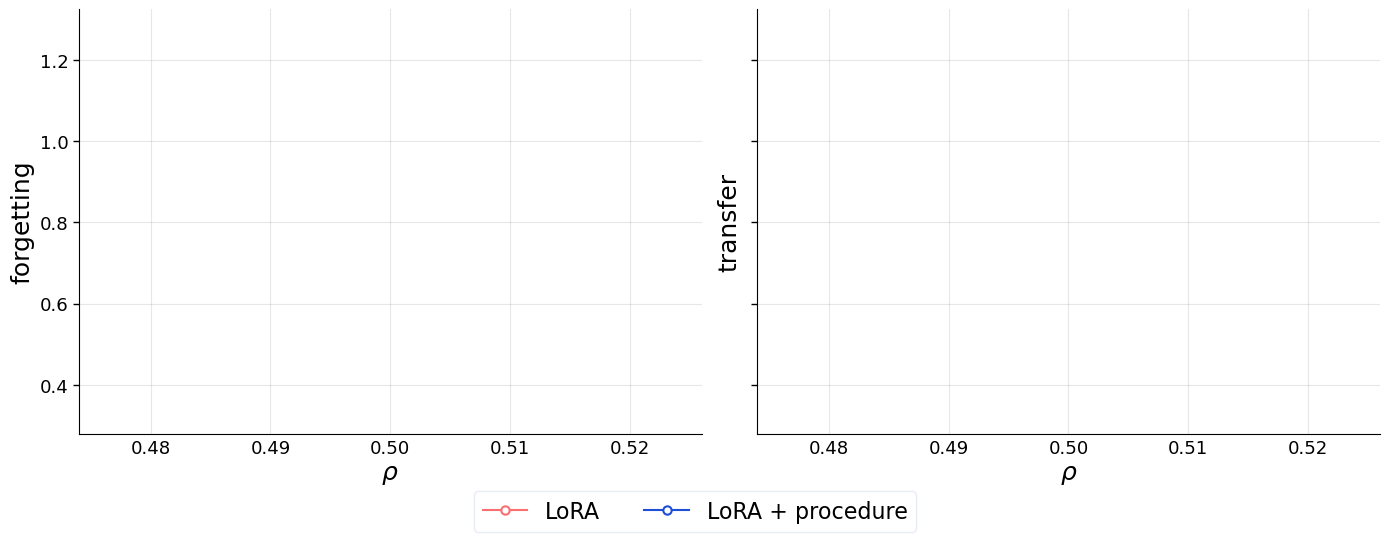

In [116]:
configs = {
    "standard": {
        "method": "standard",
        "A_only": False,
        "color": {"forgetting" : "#FA7070",
                  "transfer" : "#FA7070" },
    },
    "LoRA": {
        "method": "LoRA",
        "A_only": False,
        "color": {"forgetting" : "#1D4ED8",
                  "transfer" : "#1D4ED8" },
    },
    "LoRA + procedure": {
        "method": "LoRA",
        "A_only": True,
        "color": {"forgetting" : "#15803D",
                  "transfer" : "#15803D" },
    },
}

def select_runs(runs, method, A_only):
    
    if runs is []:
        print(f"runs empty for {method}, {A_only}. Leaving")
        return []
    
    return [
        r for r in runs
        if (
            r["metadata"]["method"] == method
            and bool(r["metadata"]["A_only"]) == A_only
            and r["metadata"]["K"] == args.K
            and r["metadata"]["M"] == args.M
            and r["metadata"]["N"] == args.N
            and r["metadata"]["L"] == args.L
            and r["metadata"]["alpha"] == args.alpha
        )
    ]

path_to_sim = os.path.join(
    args.path_to_res_folder,
    f"run_K={args.K}_M={args.M}.npy"
)

path_to_sim_ODEs = os.path.join(
    args.path_to_res_folder,
    f"ODES_K={args.K}_M={args.M}.npy"
)

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

#PLOTTING SCHEME

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)

for label, cfg in configs.items():
    sim_runs = select_runs(all_sim_runs,cfg["method"],cfg["A_only"])
    ode_runs = select_runs(all_ode_runs,cfg["method"], cfg["A_only"])

    plot_metric_vs_rho(
        ax1,
        runs_sim=sim_runs,
        runs_odes=ode_runs,
        metric_type="forgetting",
        label=label,
        color=cfg["color"],
    )

    plot_metric_vs_rho(
        ax2,
        runs_sim=sim_runs,
        runs_odes=ode_runs,
        metric_type="transfer",
        label=label,
        color=cfg["color"],
    )

# --- Global Legend Layout ---
# Grab the legend handles and labels from the first axis
handles, labels = ax1.get_legend_handles_labels()

import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([], [], color='#FA7070', marker='o', linestyle='-', 
                  markersize=6, markerfacecolor='white', markeredgewidth=1.5, label='standard'),
    mlines.Line2D([], [], color='#1D4ED8', marker='o', linestyle='-', 
                  markersize=6, markerfacecolor='white', markeredgewidth=1.5, label='LoRA'),
    mlines.Line2D([], [], color='#15803D', marker='o', linestyle='-', 
                  markersize=6, markerfacecolor='white', markeredgewidth=1.5, label='LoRA + procedure')
]
fig.legend(
    handles=legend_handles, 
    labels=labels, 
    loc='lower center', 
    ncol=3, 
    frameon=True, 
    edgecolor='#e2e8f0', 
    facecolor='white',
    fontsize=16
)

# Unique y axis
ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()
global_ymin = min(ymin1, ymin2)
global_ymax = max(ymax1, ymax2)
unified_ylim = (global_ymin, global_ymax)

for ax in [ax1, ax2]:
    ax.set_ylim(unified_ylim)
    ax.tick_params(
        axis='y',          # Target the vertical axis
        which='both',      # Apply to major and minor ticks
        left=True,         # Ensure the tick marks are drawn on the left border
        direction='out',   # Point the dashes outward away from the data lines
        length=4,          # Precise length of the little dash in points
        width=1.0          # Match the thickness of your plot spines
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
ax2.set_yticklabels([])
plt.tight_layout()
fig.subplots_adjust(bottom=0.20) 

plt.savefig("metrics_vs_rho.pdf", bbox_inches='tight')
plt.show()
    

# 4. Plasticity-Elasticity Tradeoff

{'method': 'standard', 'A_only': False, 'colors': ['#FA7070', '#FDCEDF']}
{'method': 'LoRA', 'A_only': False, 'colors': ['#1D4ED8', '#93C5FD']}
{'method': 'LoRA', 'A_only': True, 'colors': ['#15803D', '#86EFAC']}


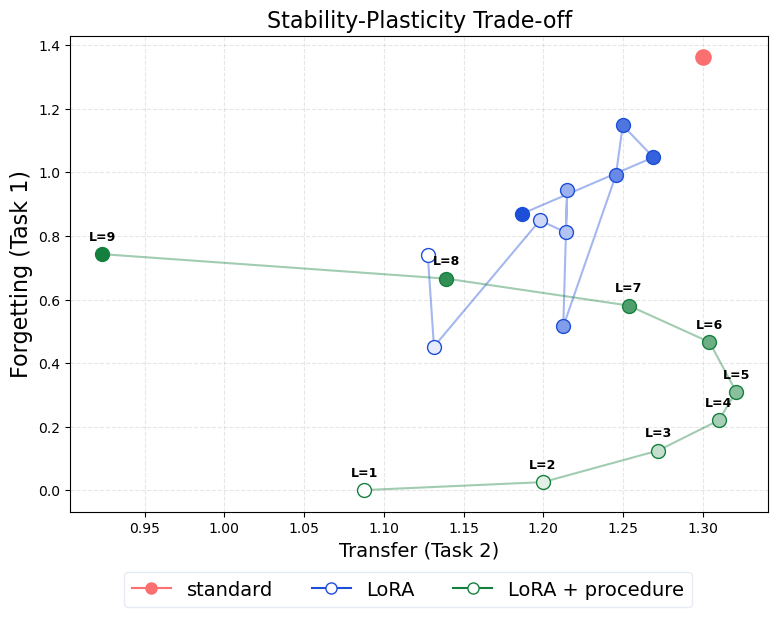

In [154]:
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

fig, ax = plt.subplots(figsize=(9, 7))

for label, cfg in configs.items():
    tradeoff_data = {}
    
    for run in all_ode_runs:
        if (run["metadata"]["method"] == cfg["method"] and 
            bool(run["metadata"]["A_only"]) == cfg["A_only"]):
            L = int(run["metadata"]["L"])
            
            metrics = compute_metric(run, "transfer", ODES=True, integration_step=args.integration_step)
            forg_metrics = compute_metric(run, "forgetting", ODES=True, integration_step=args.integration_step)
            
            if metrics and forg_metrics:
                tradeoff_data[L] = (metrics[1], forg_metrics[0])
    
    if not tradeoff_data: continue

    sorted_ranks = sorted(tradeoff_data.keys())
    transfers = [tradeoff_data[L][0] for L in sorted_ranks]
    forgettings = [tradeoff_data[L][1] for L in sorted_ranks]
    print(cfg)
    base_color = cfg["colors"][0]

    # 4. Plotting Logic
    if label == "standard":
        # Standard: Single point (or cluster), plot as a solid filled dot
        ax.scatter(transfers, forgettings, color=base_color, s=120, zorder=5, label=label)
    else:
        # LoRA/LoRA+Procedure: Gradient progression
        cmap = mcolors.LinearSegmentedColormap.from_list(f"grad_{label}", ["#FFFFFF", base_color])
        norm = mcolors.Normalize(vmin=min(sorted_ranks), vmax=max(sorted_ranks))
        
        # Plot the path line
        ax.plot(transfers, forgettings, linestyle='-', color=base_color, alpha=0.4)
        
        # Plot gradient points
        for L, x, y in zip(sorted_ranks, transfers, forgettings):
            ax.scatter(x, y, color=cmap(norm(L)), edgecolors=base_color, s=100, zorder=3)
            
            # Only annotate if it is the target method
            if label == "LoRA + procedure":
                ax.annotate(f"L={L}", (x, y), textcoords="offset points", 
                            xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

# 5. Finalize Legend and Axes
legend_handles = [
    mlines.Line2D([], [], color='#FA7070', marker='o', markersize=8, markerfacecolor='#FA7070', label='standard'),
    mlines.Line2D([], [], color='#1D4ED8', marker='o', markersize=8, markerfacecolor='white', label='LoRA'),
    mlines.Line2D([], [], color='#15803D', marker='o', markersize=8, markerfacecolor='white', label='LoRA + procedure')
]

fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=True, 
           edgecolor='#e2e8f0', facecolor='white', fontsize=14, bbox_to_anchor=(0.5, 0.05))

ax.set_xlabel("Transfer (Task 2)", fontsize=14)
ax.set_ylabel("Forgetting (Task 1)", fontsize=16)
ax.set_title("Stability-Plasticity Trade-off", fontsize=16)
ax.grid(True, linestyle='--', alpha=0.3)
fig.subplots_adjust(bottom=0.20)
plt.savefig("Stability-Plasticity_Trade-off.pdf", bbox_inches='tight')
plt.show()

# 5. Order parameters

In [60]:
# Mapping dictionary for clean LaTeX rendering
TITLE_MAP = {
    "Ha": r"$\mathbf{H_a}$",
    "Hb": r"$\mathbf{H_b}$",
    "Xi": r"$\mathbf{\Xi}$",
    "D": r"$\mathbf{D}$",
    "Phi": r"$\mathbf{\Phi}$",
    "Gamma": r"$\mathbf{\Gamma}$",
    "Lambda": r"$\mathbf{\Lambda}$",
    "Q": r"$\mathbf{Q}$",
    "R": r"$\mathbf{R}$",
    "U": r"$\mathbf{U}$"
}


def plot_order_parameters(df_ODES_run, list_to_plot, args, df_run=None, task=None, absval=True, log=None):
    active_ops = [k for k, v in list_to_plot.items() if v]
    num_plots = len(active_ops)
    if num_plots == 0: return

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(False)
    # Define a base palette for each OP panel
    
    base_palette = cm.tab10(np.linspace(0, 1, num_plots))
    markevery_sim = 1
    
    cols = 2
    rows = int(np.ceil(num_plots / cols))
    plot_size = 4 
    fig, axes = plt.subplots(rows, cols, figsize=(cols * plot_size, rows * plot_size), squeeze=False)
    axes_flat = axes.flatten()

    global_xmin=0
    global_xmax=0
    for op in active_ops:
        ode_steps = np.array(df_ODES_run["steps"][op]) * args.integration_step * args.N
        global_xmin = min(global_xmin, np.min(ode_steps))
        global_xmax = max(global_xmax, np.max(ode_steps))
    
    for idx, op in enumerate(active_ops):
        ax = axes_flat[idx]
        base_color = base_palette[idx] # Base color for this OP
        ax.xaxis.set_major_formatter(formatter)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))

        
        # Prepare Data
        ode_steps = np.array(df_ODES_run["steps"][op]) * args.integration_step * args.N
        ode_vals = np.asarray(df_ODES_run[op])
        
        P = args.alpha * args.N
        mask_o = (ode_steps <= P) if task == 1 else (ode_steps >= P if task == 2 else np.ones_like(ode_steps, bool))

        sim_data = None
        if df_run is not None:
            sim_steps = np.array(df_run["steps"][op])
            sim_vals = np.asarray(df_run[op])
            mask_s = (sim_steps <= P) if task == 1 else (sim_steps >= P if task == 2 else np.ones_like(sim_steps, bool))
            sim_data = (sim_steps[mask_s], sim_vals[mask_s])

        _plot_single_op(ax, sim_data, (ode_steps[mask_o], ode_vals[mask_o]), op, P, absval, log, markevery_sim, base_color)

    for i in range(num_plots, len(axes_flat)): fig.delaxes(axes_flat[i])
    
# --- The fix for perfectly square subplots ---
    for ax in axes_flat:
        for side in ['top', 'right', 'left', 'bottom']:
            ax.spines[side].set_linewidth(0.5)
        ax.set_xlabel(r"$s$", fontsize=10)
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_box_aspect(1)
        ax.tick_params(labelsize=8)
    
    # Use explicit spacing instead of tight_layout to prevent resizing
    fig.subplots_adjust(wspace=0.01, hspace=0.3)
    plt.tight_layout()
    plt.savefig("results/order_parameters.pdf")
    plt.show()

def _plot_single_op(ax, sim_data, ode_data, name, P, absval, log, markevery_sim, base_color):
    o_steps, o_vals = ode_data
    first = o_vals[0]
    
    # --- Scalar Case ---
    if np.isscalar(first):
        v_ode = np.abs(o_vals) if absval else o_vals
        ax.plot(o_steps, np.log10(v_ode) if log else v_ode, "--", color=base_color, lw=1.5)
        
        if sim_data:
            s_steps, s_vals = sim_data
            v_sim = np.abs(s_vals) if absval else s_vals
            # Simulation as dots
            ax.plot(s_steps, np.log10(v_sim) if log else v_sim, 
                    linestyle='None', marker='o', markersize=5, 
                    color=base_color, markerfacecolor='white', markevery=markevery_sim,
                    markeredgewidth=1.2)

    # --- Vector / Matrix Case ---
    else:
        shape = np.array(first).shape
        if len(shape) in [1, 2]:
            total_elements = np.prod(shape)
            indices = [(i,) if len(shape)==1 else (i,j) for i in range(shape[0]) for j in range(shape[1] if len(shape)==2 else 1)]
            alphas = np.linspace(0.6, 1.0, total_elements)
            
            for idx, dims in enumerate(indices):
                
                line_color = [c * alphas[idx] + (1 - alphas[idx]) for c in mcolors.to_rgb(base_color)]
                
                # ODE (Theory)
                v_ode = np.array([x[dims] for x in o_vals], dtype=np.float64)
                if absval: v_ode = np.abs(v_ode)
                ax.plot(o_steps, np.log10(v_ode) if log else v_ode, color=line_color, lw=1)
                
                # Simulation as dots
                if sim_data:
                    s_steps, s_vals = sim_data
                    v_sim = np.array([x[dims] for x in s_vals], dtype=np.float64)
                    if absval: v_sim = np.abs(v_sim)
                    ax.plot(s_steps, np.log10(v_sim) if log else v_sim, 
                            linestyle='None', marker='o', markersize=4, 
                            color=line_color, markerfacecolor='white', markevery=markevery_sim,
                            markeredgewidth=1.0)

    formatted_title = TITLE_MAP.get(name, name)
    ax.axvline(x=P, color="red", linestyle=":", lw=1)
    ax.set_title(formatted_title)
    ax.grid(alpha=0.3)

No matching configurations found in run_K=10_M=5.npy!


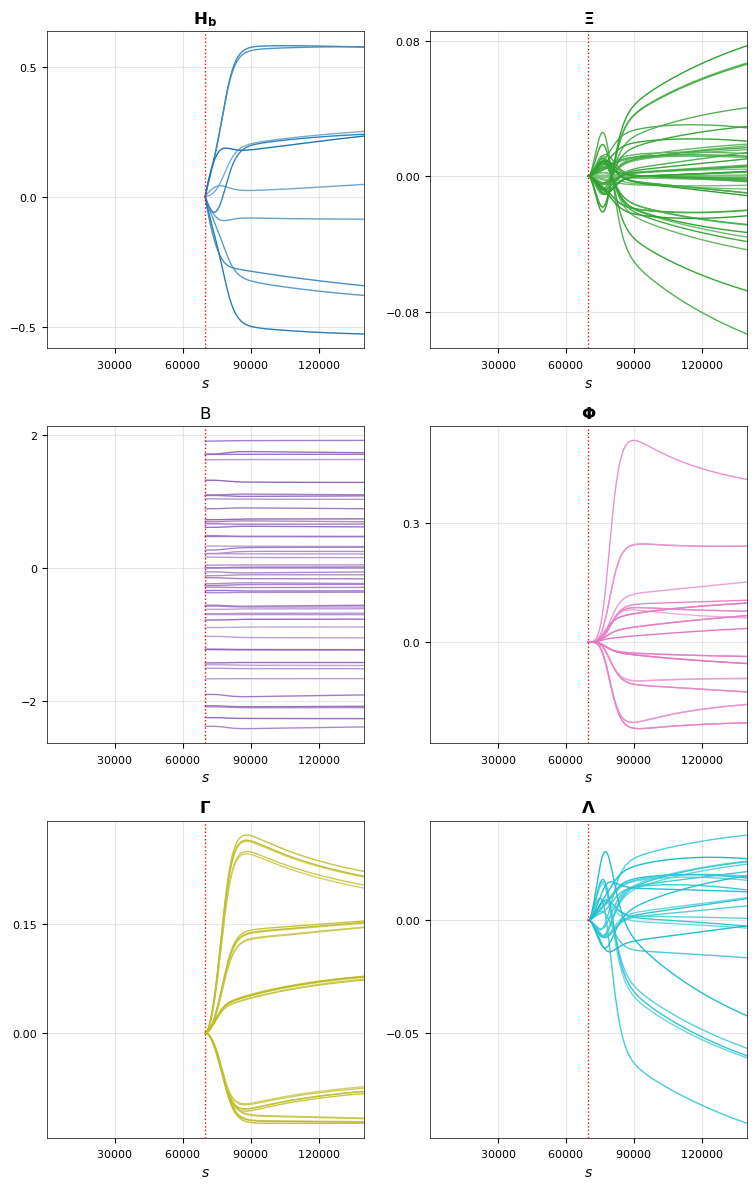

In [61]:

list_to_plot={"Q" : False,
                "R" : False,
                "U" : False,
                "Ha" : False,
                "Hb" : True,
              "Xi" : True,
              "B" : True,
              "Phi" : True,
              "Gamma" : True,
              "Lambda" : True,
              }
df_run = runs_to_dict(path_to_sim, args)
df_ODES_run = runs_to_dict(path_to_sim_ODEs, args)

plot_order_parameters(df_ODES_run,list_to_plot, args, df_run, absval=False)

In [138]:
import numpy as np
import os

def delete_runs_with_args(path, args):
    """
    Deletes runs from the .npy file that match the provided args.
    """
    
    # 1. Re-use the boolean conversion logic
    def to_bool(val):
        if isinstance(val, str):
            return val.lower() in ("true", "1")
        return bool(val)

    # 2. Define the predicate function (True means "delete this run")
    def match_predicate(meta):
        # We return True if all fields match, indicating this is a run to delete
        return (
            int(meta.get("L", 0)) == int(args.L) and
            float(meta.get("beta", 0)) == float(args.beta) and
            str(meta.get("method", "")) == str(args.method) and
            np.isclose(float(meta.get("rho", 0)), float(args.rho)) and
            int(meta.get("M", 0)) == int(args.M) and
            int(meta.get("K", 0)) == int(args.K) and
            int(meta.get("N", 0)) == int(args.N) and
            to_bool(meta.get("A_only", False)) == to_bool(args.A_only) and 
            float(meta.get("alpha", 0)) == float(args.alpha)
        )

    # 3. Use your existing ExperimentLogger method
    ExperimentLogger.delete_runs(path, match_predicate)

# --- Usage Example ---
path_to_sim = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
#delete_runs_with_args(path_to_sim, args)